# Sentiment Analysis on Amazon Product Reviews

### Internship Project - Week 1

### Objective:
#### The objective of this project is to analyze Amazon product reviews and classify them into Positive, Negative, or Neutral sentiments using TextBlob.

In [58]:
# Importing Libraries
import pandas as pd

In [59]:
data = pd.read_csv("Reviews.csv")

In [63]:
# Using first 5000 rows
data = data.head(5000)
data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES..."


In [64]:
data.shape

(5000, 10)

### Task 1 — Data Loading & Exploration 

In [65]:
# Displaying first10 rows
data.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [66]:
# How much rows and columns are there
data.shape

(5000, 10)

In [ ]:
# column contains the review text 
The column containing the review text is "Text".

### Task 2 — Data Cleaning

In [67]:
#Keep only required columns
clean_data = data[['Text', 'Score']].copy()

In [68]:
clean_data.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [69]:
#Check for Missing Data
clean_data.isnull().sum()


Text     0
Score    0
dtype: int64

##### The "Text" column contains no missing values, so no rows were removed based on missing review text.

In [70]:
# Remove null values
clean_data = clean_data.dropna(subset=['Text'])

In [71]:
clean_data

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5
...,...,...
4995,I really wanted to like these.<br /><br />Firs...,2
4996,I was not impressed with these cookies when I ...,1
4997,The cookies came sealed and seem to be high qu...,3
4998,"These taste very good, but aren't like the BES...",4


In [72]:
#Remove empty text
clean_data = data[data['Text'].str.strip() != ""]
clean_data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES..."


In [73]:
#check for duplicate
clean_data = data.duplicated()
clean_data

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [74]:
#Number of duplicate data
clean_data = data.duplicated(subset=['Text']).sum()

In [75]:
clean_data

16

In [78]:
# Reset index
clean_data = data.reset_index(drop=True)

In [79]:
clean_data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES..."


### Task 3 — Sentiment Analysis 

In [82]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [83]:
from textblob import TextBlob

In [84]:
# Calculate Polarity Score
data['Polarity'] = data['Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

In [85]:
data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Polarity
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,0.450000
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,-0.033333
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,0.133571
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,0.166667
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,0.483333
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...,-0.083333
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...,0.302273
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...,0.354615
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES...",0.345417


In [86]:
# Convert Score → Sentiment
def sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

data['Sentiment'] = data['Polarity'].apply(sentiment)

In [87]:
data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Polarity,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,0.450000,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,-0.033333,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,0.133571,Positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,0.166667,Positive
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,0.483333,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...,-0.083333,Negative
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...,0.302273,Positive
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...,0.354615,Positive
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES...",0.345417,Positive


In [88]:
# keep only 3 main columns
data[['Text', 'Polarity', 'Sentiment']].head(5000)

,Text,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,-0.033333,Negative
2,This is a confection that has been around a fe...,0.133571,Positive
3,If you are looking for the secret ingredient i...,0.166667,Positive
4,Great taffy at a great price. There was a wid...,0.483333,Positive
...,...,...,...
4995,I really wanted to like these.<br /><br />Firs...,-0.083333,Negative
4996,I was not impressed with these cookies when I ...,0.302273,Positive
4997,The cookies came sealed and seem to be high qu...,0.354615,Positive
4998,"These taste very good, but aren't like the BES...",0.345417,Positive


### Task 4 — Visualization (Minimum 3 charts)

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# count the sentiment
sentiment_counts = data['Sentiment'].value_counts()

In [90]:
sentiment_counts

Sentiment
Positive    4416
Negative     504
Neutral       80
Name: count, dtype: int64

#### Chart 1 — Bar Chart (Count of Sentiments)

Text(0, 0.5, 'Number of Reviews')

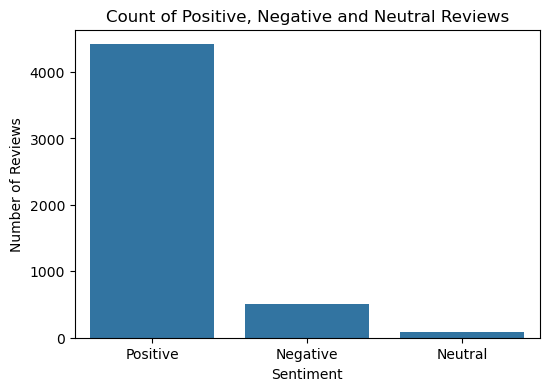

In [91]:
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)

plt.title("Count of Positive, Negative and Neutral Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.savefig("charts/sentiment_count.png")

#### Chart 2 — Pie Chart (Percentage)

Text(0.5, 1.0, 'Percentage Distribution of Sentiments')

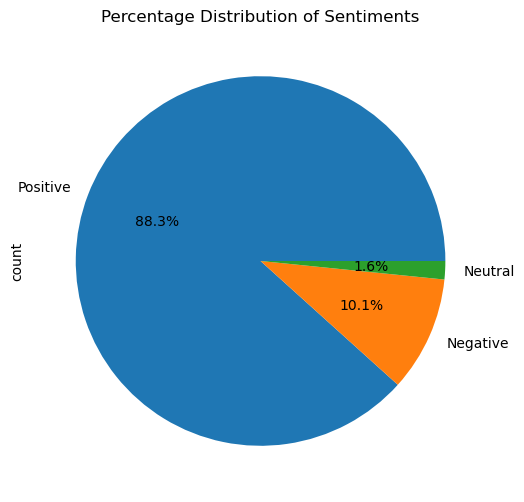

In [92]:
plt.figure(figsize=(6,6))

data['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%')

plt.title("Percentage Distribution of Sentiments")
# plt.savefig("charts/sentiment_pie.png")

#### Chart 3 - most common words in negative reviews

In [93]:
# Take only negative reviews
negative_reviews = data[data['Sentiment'] == 'Negative']

In [94]:
# Combine all text
text = " ".join(negative_reviews['Text'])

In [95]:
# Make lowercase and split
words = text.lower().split()

In [96]:
# import counter
from collections import Counter

In [97]:
# Count words
word_counts = Counter(words)

In [98]:
common_words = word_counts.most_common(10)
print(common_words)

[('the', 1504), ('i', 1171), ('and', 921), ('a', 834), ('to', 787), ('of', 648), ('it', 594), ('this', 506), ('is', 488), ('in', 418)]


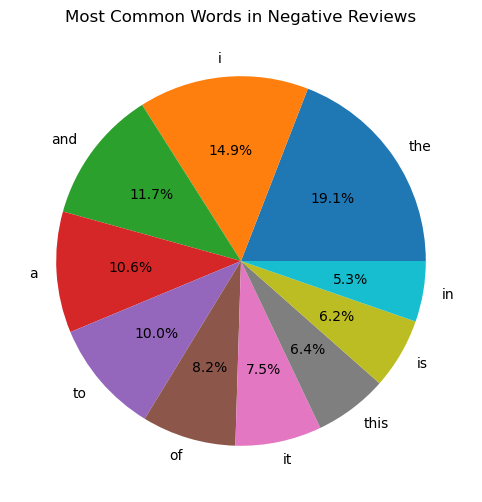

In [100]:
import matplotlib.pyplot as plt

# Take top 5 words only
top_words = word_counts.most_common(10)
words, freq = zip(*top_words)
plt.figure(figsize=(8,6))
plt.pie(freq, labels=words, autopct='%1.1f%%')
plt.title("Most Common Words in Negative Reviews")
plt.show()


##### A pie chart was used to show the percentage distribution of the most frequent words in negative reviews.  

#### Chart 3 - rating vs sentiment comparison

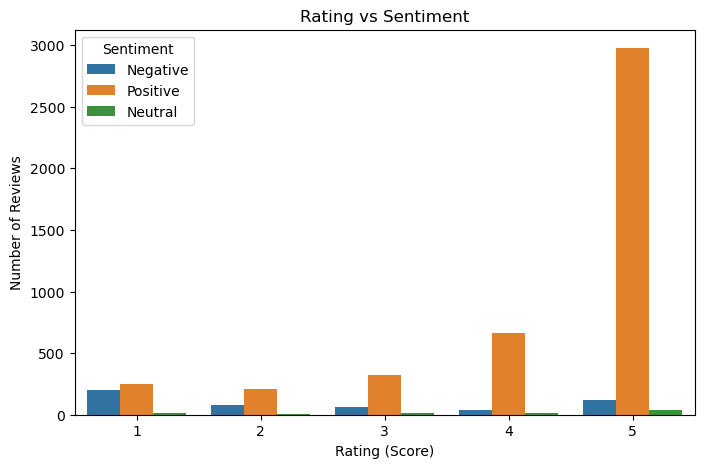

In [102]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x='Score', hue='Sentiment')

plt.title("Rating vs Sentiment")
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Reviews")

plt.show()
plt.savefig("charts/rating_vs_sentiment.png")

#### chart 3 - Review Length vs Sentiment

In [104]:
# Create review length 
data['Review_Length'] = df['Text'].apply(lambda x: len(str(x)))

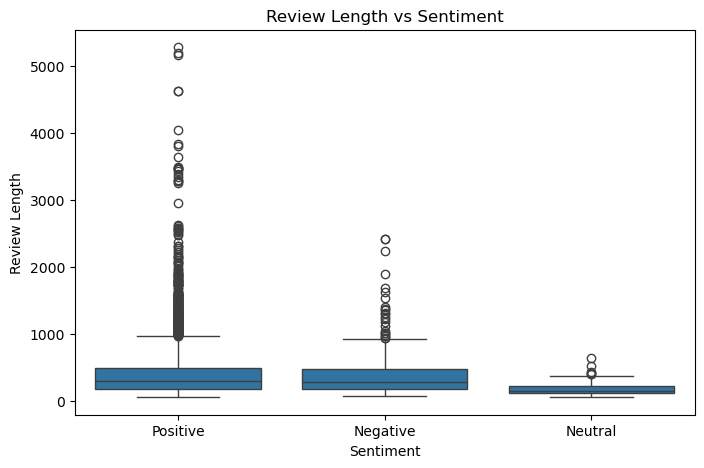

In [105]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x='Sentiment', y='Review_Length')

plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")

plt.show()
# plt.savefig("charts/review_length_sentiment.png")

### Review Length vs Sentiment

**This chart shows the relationship between review length and sentiment.**  
**Negative reviews tend to be longer, indicating that dissatisfied customers provide more detailed feedback compared to satisfied customers.**

**Negative reviews are generally longer than positive reviews, as shown by the higher median and distribution in the boxplot.** 
**Although some positive reviews are very long, they are outliers and do not represent the majority.**

#### Task 5 — Insights & Summary

#### What percentage of reviews are positive?

In [106]:
data['Sentiment'].value_counts(normalize=True)['Positive'] * 100

88.32

#### What do customers mostly complain about in negative reviews?

****Customers mostly complain about problems related to product quality and taste in negative reviews.****
****Many reviews include words like "bad", "poor", and "taste", which means that customers are not happy with the quality or how the product tastes.****
****Some customers also feel that the product is not worth the money and does not meet their expectations.****  

#### What surprised you in the data?

****One surprising thing in the data was that some reviews had high ratings but still contained negative words.****

****Another observation was that negative reviews are usually longer than positive ones.****  
****This means that unhappy customers tend to explain their problems in more detail.****  

#### One recommendation for the business based on your findings?

****The company should focus on improving product quality and taste, as these are the main issues mentioned in negative reviews.****
    
****They should also regularly check negative feedback to understand customer problems.**** 
****By fixing these issues, the company can improve customer satisfaction and get better reviews in the future.****

#### Saving only 5000 rows

In [107]:
data.to_csv("Reviews_5000.csv", index=False)

# THANK YOU 

### Name:- Roshan Kumar
### Aspiring Data Analyst 